In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('titanic_Data.csv',usecols = ['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [7]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [8]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2,random_state = 2)

In [9]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [11]:
x_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [14]:
# train
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_train['Age_imputed'].isnull().sum(), replace=True)
    .values
)

# test
x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    x_train['Age']
    .dropna()
    .sample(x_test['Age_imputed'].isnull().sum(), replace=True)
    .values
)


In [15]:
x_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.00
10,4.0,16.7000,4.00
873,47.0,9.0000,47.00
182,9.0,31.3875,9.00
876,20.0,9.8458,20.00
...,...,...,...
534,30.0,8.6625,30.00
584,NaN,8.7125,39.00
493,71.0,49.5042,71.00
527,NaN,221.7792,0.83


C:\Users\its\AppData\Local\Temp\ipykernel_12376\375511293.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'],label = 'Original',hist = False)
C:\Users\its\AppData\Local\Temp\ipykernel_12376\375511293.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['A

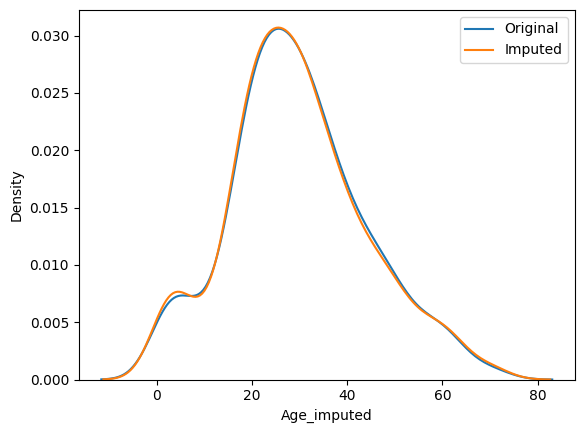

In [17]:
sns.distplot(x_train['Age'],label = 'Original',hist = False)
sns.distplot(x_train['Age_imputed'],label = 'Imputed',hist = False)

plt.legend()
plt.show()

IT is almost same

In [20]:
print('Original variable variance:', x_train['Age'].var())
print('Variance after random imputation :', x_train['Age_imputed'].var())

Original variable variance: 204.3495133904614
Variance after random imputation : 208.5972795429761


Variance me difference nhi aaya 

In [21]:
x_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,57.618175
Age,71.512440,204.349513,204.349513
Age_imputed,57.618175,204.349513,208.597280


Co-variance is change  

<Axes: >

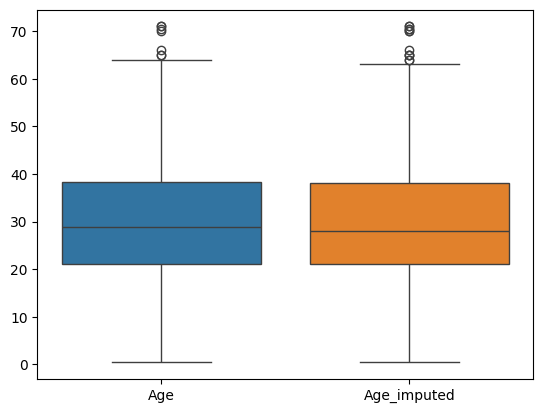

In [23]:
sns.boxplot(data = x_train[['Age','Age_imputed']])

No change in outlier, no major impact

In [27]:
for index, observation in x_train.iterrows():

    sample_value = x_train['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    ).values[0]



In [28]:
data = pd.read_csv('house-train.csv', usecols = ['GarageQual','FireplaceQu','SalePrice'])

In [29]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [30]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [31]:
x =data
y = data['SalePrice']


In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 2)

In [36]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']

x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [38]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
290,Gd,Gd,233230,Gd,Gd
343,Ex,TA,266000,TA,Ex
1136,NaN,TA,119000,TA,NaN
451,TA,TA,280000,TA,TA
1341,NaN,TA,155000,TA,NaN


In [39]:
x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

C:\Users\its\AppData\Local\Temp\ipykernel_12376\4277669966.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'

In [40]:
temp = pd.concat(
    [
        x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_imputed'].value_counts()/ len(x_train)
    ],
    axis = 1
)
temp.columns = ['original','imputed']

In [41]:
temp

,original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [43]:
temp = pd.concat(
    [
        x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
        x_train['FireplaceQu_imputed'].value_counts()/ len(x_train)
    ],
    axis = 1
)
temp.columns = ['original','imputed']
temp

,original,imputed
Gd,0.494272,0.492295
TA,0.412439,0.414384
Fa,0.040917,0.041952
Po,0.027823,0.028253
Ex,0.024550,0.023116


yadi difference jyada aaye to ye technique ko dekhege ki lagaye ya nhi

C:\Users\its\AppData\Local\Temp\ipykernel_12376\855750489.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False, label = category)
C:\Users\its\AppData\Local\Temp\ipykernel_12376\855750489.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad63

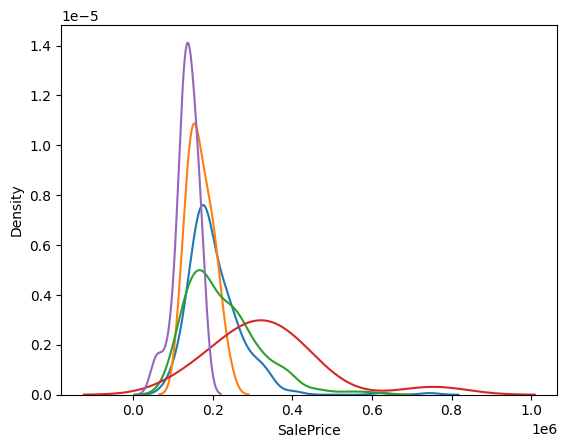

In [47]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False, label = category)
plt.show()

C:\Users\its\AppData\Local\Temp\ipykernel_12376\945787667.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False, label = category)
C:\Users\its\AppData\Local\Temp\ipykernel_12376\945787667.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed297

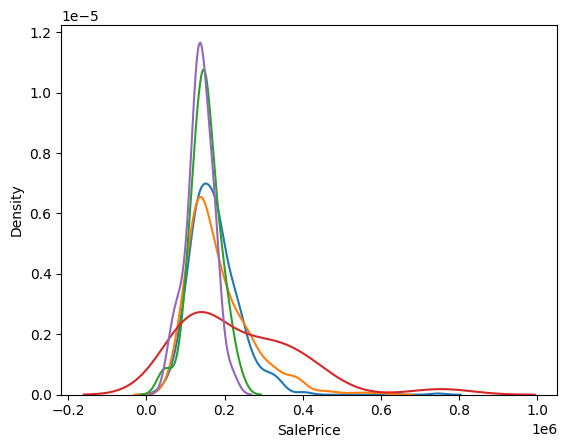

In [48]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False, label = category)
plt.show()